<a href="https://colab.research.google.com/github/Samu24042/CienciaDeDatos/blob/main/ciencia_de_datos_semana_7_modelos_arma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Taller Práctico: Generación de Datos Sintéticos con Modelos ARMA**
Maestría en Ingeniería Electrónica

Universidad de Nariño Curso

Introducción a la Ciencia de Datos

Instructor: Carlos Andrés Viteri Mera

En este cuaderno se analiza la serie de tiempo de los precios del índice S&P 500. El procedimiento es el siguiente:
1. Se extraen los rendimientos diarios de la seria.
2. Se verifica que el proceso sea estacionario (condición necesaria para aplicar la mayoría de modelos estocásticos clásicos).
3. Se ajusta un modelo ARMA (Autoregressive Moving Average) a los datos.
4. Se utiliza el modelo para simular (generar) 250 días de datos sintéticos que se  transforman de vuelta a precios proyectados.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)



## **1. Obtención de Datos y Cálculo de Rendimientos**
Se descargan los últimos 5 años de datos del S&P 500. Para que el proceso sea modelable mediante técnicas lineales y estacionarias, se trabaja con los rendimientos diarios en porcentaje y les restaremos su media para obtener un proceso de media cero.

[*********************100%***********************]  1 of 1 completed


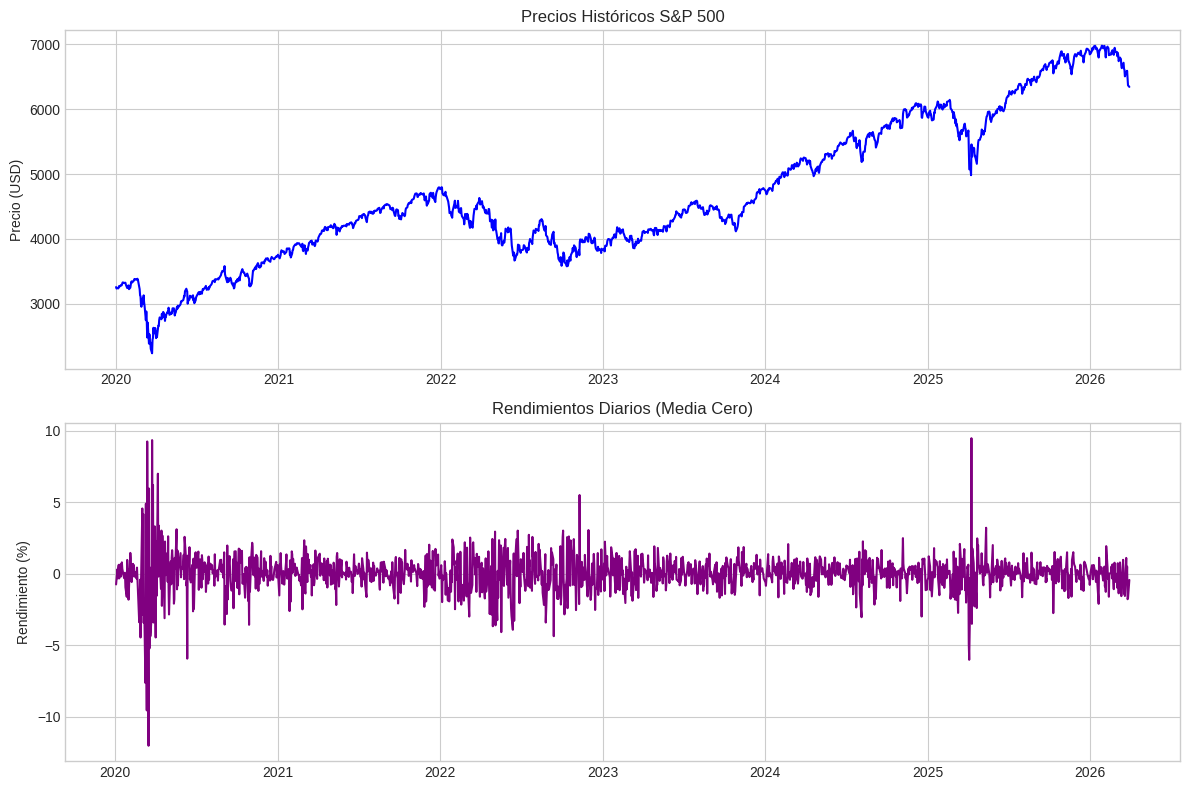

In [ ]:
# Descarga de datos
ticker = '^GSPC'
data = yf.download(ticker, start='2020-01-01', end='2026-03-31')
precios = data['Close'].squeeze()

# Cálculo de rendimientos porcentuales
rendimientos = precios.pct_change().dropna() * 100

# Convertir a proceso de media cero
media_rendimientos = rendimientos.mean()
rendimientos_mc = rendimientos - media_rendimientos

# Gráficas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(precios, color='blue')
ax1.set_title('Precios Históricos S&P 500')
ax1.set_ylabel('Precio (USD)')

ax2.plot(rendimientos_mc, color='purple')
ax2.set_title('Rendimientos Diarios (Media Cero)')
ax2.set_ylabel('Rendimiento (%)')
plt.tight_layout()
plt.show()

# **2. Prueba de Estacionariedad**
Un proceso es estacionario en sentido amplio (WSS) si su media y varianza son constantes en el tiempo, y su autocorrelación depende solo de la diferencia temporal. Se aplica la prueba estadística de Dickey-Fuller Aumentada (ADF), que es una prueba de hipótesis.

    Hipótesis Nula (H0​): La serie de tiempo tiene NO es estacionaria.
    Hipótesis Alternativa (H1​): La serie de tiempo ES estacionaria.
    
    Si el valor p (p-value) es menor a 0.05, se rechaza H0​.

In [ ]:
# Prueba ADF
resultado_adf = adfuller(rendimientos_mc)

# La hipótesis nula (H0) es: Los datos no son estacionarios

# p mide la probabilidad de que los datos observados sean obtenidos, asumiendo que
# la hipóstesis nula (H0) es verdadera. Si se obtiene p<= 0.05, los datos indican
# que hay que rechaszar la hipótesis nula.

print("--- Prueba de Dickey-Fuller Aumentada (ADF) ---")
print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"Valor p (p-value): {resultado_adf[1]:.4e}")

if resultado_adf[1] < 0.05:
    print("\nConclusión: Rechazamos H0. La serie de rendimientos ES estacionaria.")
else:
    print("\nConclusión: No podemos rechazar H0. La serie NO es estacionaria.")

--- Prueba de Dickey-Fuller Aumentada (ADF) ---
Estadístico ADF: -12.3071
Valor p (p-value): 7.2292e-23

Conclusión: Rechazamos H0. La serie de rendimientos ES estacionaria.


## **3. Estimación del Orden del Modelo ($p$ y $q$)**
Antes de ajustar un modelo ARMA(p,q), podemos estimar los valores adecuados para $p$ y $q$ analizando la Función de Autocorrelación (ACF) y la Función de Autocorrelación Parcial (PACF) de la serie estacionaria.

ACF: Permite identificar el orden q de la parte de promedios móviles (MA). Buscamos el retardo (lag) después del cual la autocorrelación cae abruptamente a cero.

PACF: Permite identificar el orden p de la parte autorregresiva (AR). Mide la correlación directa entre la variable actual y sus valores pasados, descontando el efecto de los retardos intermedios.

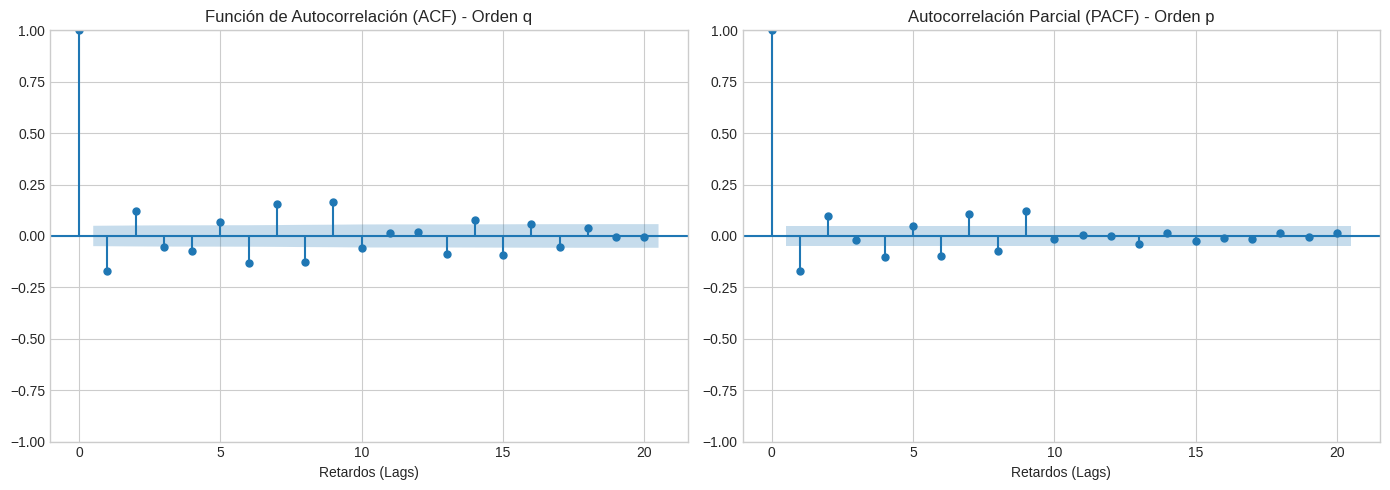

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Autocorrelación (ACF) para identificar 'q' (MA)
plot_acf(rendimientos_mc, lags=20, ax=ax1, title="Función de Autocorrelación (ACF) - Orden q")
ax1.set_xlabel("Retardos (Lags)")

# Gráfica de Autocorrelación Parcial (PACF) para identificar 'p' (AR)
plot_pacf(rendimientos_mc, lags=20, ax=ax2, title="Autocorrelación Parcial (PACF) - Orden p", method='ywm')
ax2.set_xlabel("Retardos (Lags)")

plt.tight_layout()
plt.show()

# Análisis para los estudiantes:
# Los valores significativos (fuera de la franja sombreada de confianza) en los
# primeros retardos de la PACF nos sugieren el orden p, mientras que los de la ACF
# nos sugieren el orden q.

# **4. Ajuste del Modelo ARMA**
Los procesos ARMA($p,q$) combinan una parte autorregresiva (AR) de orden $p$ y una parte de promedios móviles (MA) de orden $q$. Ajustaremos un modelo ARMA(2,2) a nuestros rendimientos de media cero para capturar su dinámica estocástica.

                               SARIMAX Results                                
Dep. Variable:                  ^GSPC   No. Observations:                 1567
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -2570.996
Date:                Sat, 18 Apr 2026   AIC                           5153.993
Time:                        02:41:29   BIC                           5186.134
Sample:                             0   HQIC                          5165.941
                               - 1567                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.564e-05      0.030     -0.001      1.000      -0.058       0.058
ar.L1         -1.7326      0.017   -100.467      0.000      -1.766      -1.699
ar.L2         -0.8762      0.016    -54.504      0.0

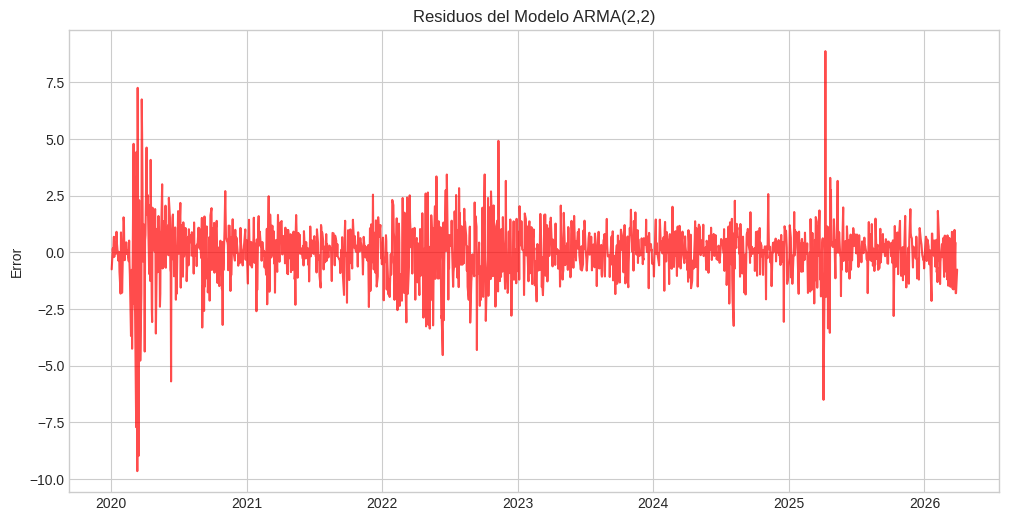

In [ ]:
# Ajuste de un modelo ARMA(2,2). En statsmodels se usa ARIMA(p,d,q) con d=0.
orden_arma = (2, 0, 2)
modelo_arma = ARIMA(rendimientos_mc, order=orden_arma)
resultado_arma = modelo_arma.fit()

print(resultado_arma.summary())

# Graficamos los residuos del modelo (deberían comportarse como ruido blanco)
residuos = resultado_arma.resid

plt.figure()
plt.plot(residuos, color='red', alpha=0.7)
plt.title('Residuos del Modelo ARMA(2,2)')
plt.ylabel('Error')
plt.show()

# **5. Generación de Datos Sintéticos y Reconstrucción de Precios**
Utilizaremos las propiedades estadísticas aprendidas por el modelo ARMA para generar (simular) una trayectoria futura de 250 días (aproximadamente un año de negociación).
Para volver a la escala de precios reales:

Añadimos la media histórica a los rendimientos sintéticos.
Reconstruimos los precios usando el último precio real conocido como semilla, aplicando la fórmula de interés compuesto iterativo: $P_t​=P_{t−1}​×(1+R_t​/100)$.

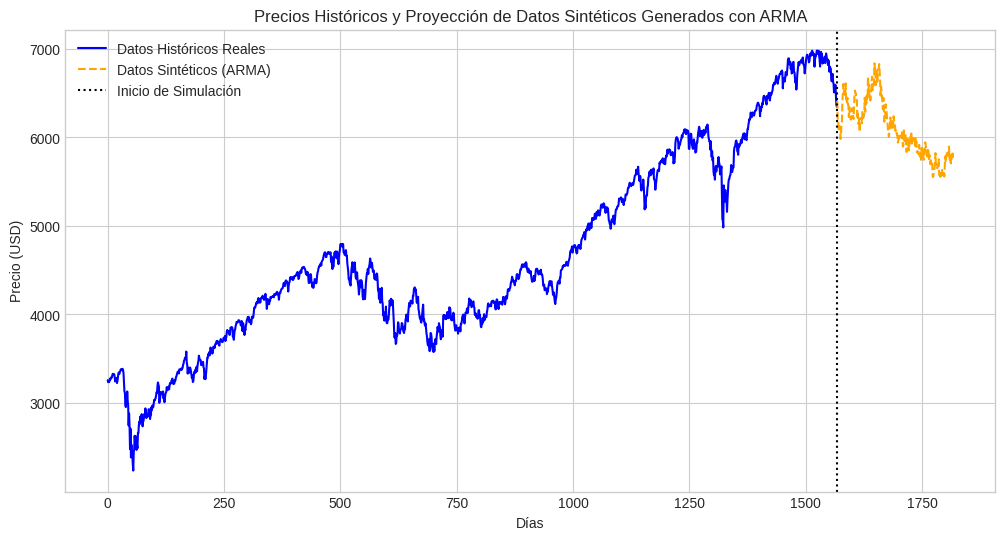

In [ ]:
# 1. Simular 250 días de rendimientos de media cero
dias_simulacion = 250
rendimientos_sinteticos_mc = resultado_arma.simulate(nsimulations=dias_simulacion)

# 2. Añadir la media para obtener rendimientos proyectados reales
rendimientos_sinteticos = rendimientos_sinteticos_mc + media_rendimientos

# 3. Reconstruir los precios
precio_inicial = precios.iloc[-1]
precios_sinteticos = precio_inicial * (1 + rendimientos_sinteticos / 100).cumprod()

# Gráfica de los resultados proyectados
plt.figure(figsize=(12, 6))
# Creamos un eje de tiempo ficticio para los datos futuros
dias_futuros = np.arange(len(precios), len(precios) + dias_simulacion)

plt.plot(np.arange(len(precios)), precios.values, label='Datos Históricos Reales', color='blue')
plt.plot(dias_futuros, precios_sinteticos.values, label='Datos Sintéticos (ARMA)', color='orange', linestyle='--')

plt.title('Precios Históricos y Proyección de Datos Sintéticos Generados con ARMA')
plt.xlabel('Días')
plt.ylabel('Precio (USD)')
plt.axvline(len(precios), color='black', linestyle=':', label='Inicio de Simulación')
plt.legend()
plt.show()

## **Advertencia**
El modelo ARMA genera datos sintéticos que siguen las mismas estadísticas de los datos pasados.

Sin embargo, las realizaciones del proceso ARIMA no consideran los datos inmediatamente anteriores a la predicción.

## Reto 1
Usando el modelo ARMA, genere 1000 posibles realizaciones de la serie de tiempo y grafique 20 de ellas como continuaciones de la gráfica de datos pasados.

Genere un histograma de los datos sintéticos en el tiempo 250 (un año después de los datos reales). Genere también la CDF empírica de los datos sintéticos en el tiempo 250 y determine cuál es la probabilidad aproximada de que el índice se encuentre por debajo del último dato real.

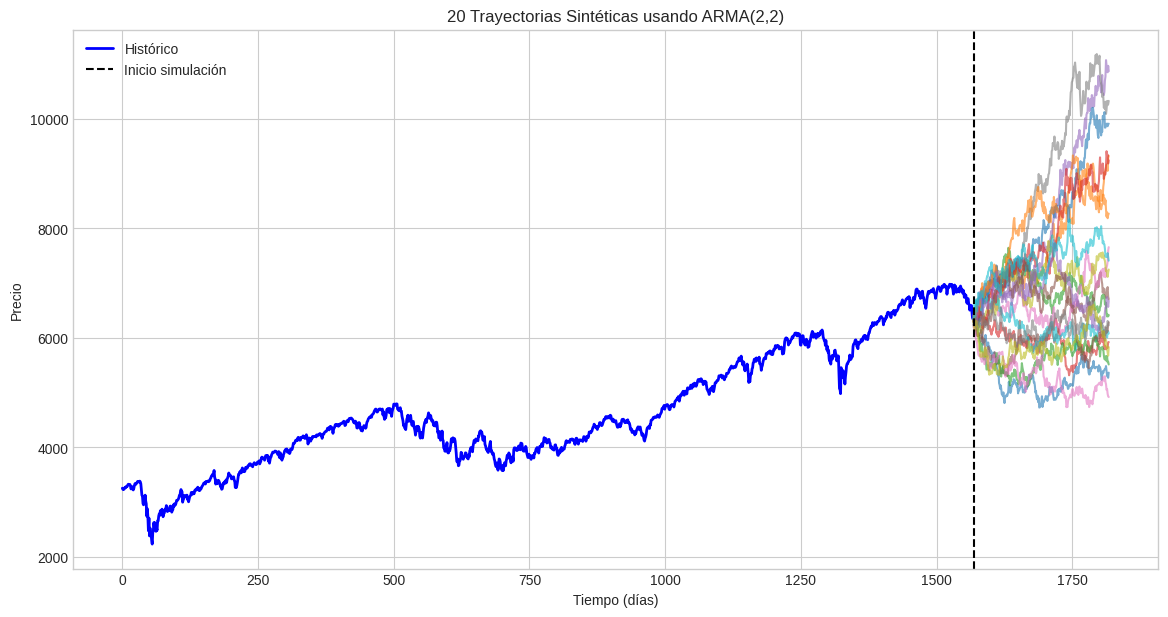

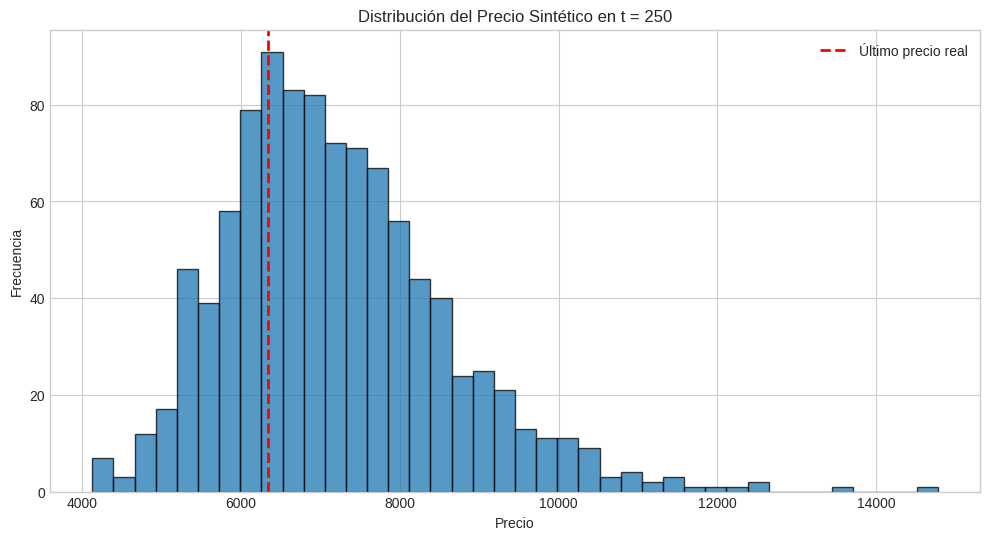

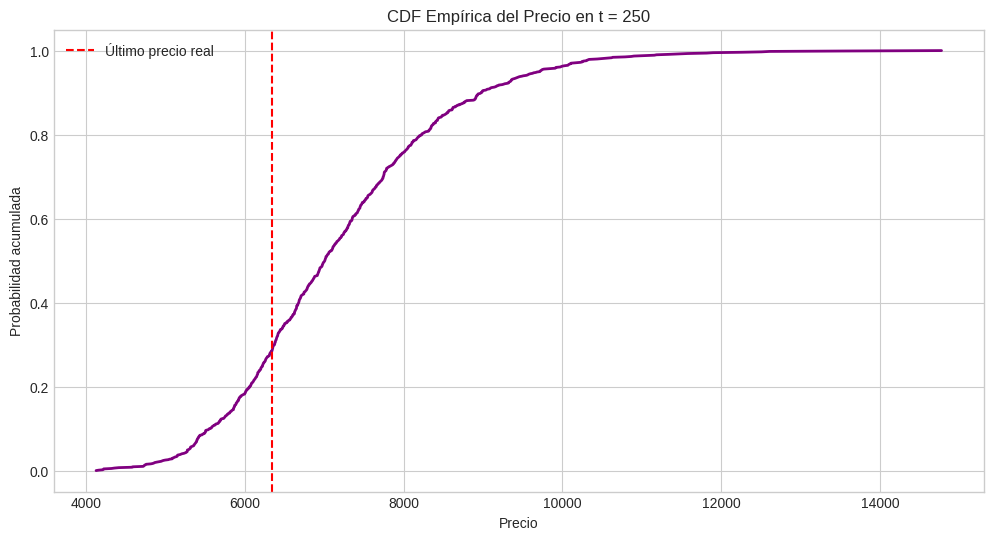

Último precio real: 6343.72
Probabilidad aproximada de caer por debajo de ese valor en t=250:
P(X < 6343.72) = 0.2850
Equivale a 28.50%


In [ ]:
n_simulaciones = 1000
dias_simulacion = 250

precio_inicial = precios.iloc[-1]
ultimo_precio_real = precio_inicial

# Matriz para guardar trayectorias
trayectorias = np.zeros((n_simulaciones, dias_simulacion))

# GENERAR 1000 REALIZACIONES
for i in range(n_simulaciones):

    # Simular rendimientos media cero
    rend_mc = resultado_arma.simulate(nsimulations=dias_simulacion)

    # Añadir media histórica
    rend = rend_mc + media_rendimientos

    # Reconstrucción de precios
    precios_sim = precio_inicial * (1 + rend / 100).cumprod()

    trayectorias[i, :] = precios_sim.values

# GRAFICAR 20 REALIZACIONES COMO CONTINUACIÓN

plt.figure(figsize=(14,7))

# Datos históricos
plt.plot(np.arange(len(precios)), precios.values,
         color='blue', linewidth=2, label='Histórico')

# 20 trayectorias
for i in range(20):
    plt.plot(np.arange(len(precios), len(precios)+dias_simulacion),
             trayectorias[i,:],
             alpha=0.6)

plt.axvline(len(precios), color='black', linestyle='--', label='Inicio simulación')
plt.title("20 Trayectorias Sintéticas usando ARMA(2,2)")
plt.xlabel("Tiempo (días)")
plt.ylabel("Precio")
plt.legend()
plt.show()

# HISTOGRAMA DEL PRECIO EN t = 250
precios_t250 = trayectorias[:, -1]

plt.figure(figsize=(12,6))
plt.hist(precios_t250, bins=40, edgecolor='black', alpha=0.75)
plt.axvline(ultimo_precio_real, color='red', linestyle='--', linewidth=2, label='Último precio real')
plt.title("Distribución del Precio Sintético en t = 250")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# 4. CDF EMPÍRICA
x = np.sort(precios_t250)
cdf = np.arange(1, len(x)+1) / len(x)

plt.figure(figsize=(12,6))
plt.plot(x, cdf, color='purple', linewidth=2)
plt.axvline(ultimo_precio_real, color='red', linestyle='--', label='Último precio real')
plt.title("CDF Empírica del Precio en t = 250")
plt.xlabel("Precio")
plt.ylabel("Probabilidad acumulada")
plt.legend()
plt.grid(True)
plt.show()


# 5. PROBABILIDAD INDICE BAJO ULTIMO DATO REAL
probabilidad = np.mean(precios_t250 < ultimo_precio_real)

print(f"Último precio real: {ultimo_precio_real:.2f}")
print(f"Probabilidad aproximada de caer por debajo de ese valor en t=250:")
print(f"P(X < {ultimo_precio_real:.2f}) = {probabilidad:.4f}")
print(f"Equivale a {probabilidad*100:.2f}%")

## Reto 2

Utilice la misma metodología descrita anteriormente para modelar cualquier serie de tiempo de su interés como un proceso ARMA y generar datos sintéticos.

Si los datos $x$ no son estacionarios puede utilizar algunas de las siguientes transformaciones:
1. Trabajar con la serie de tiempo $y=\log(x)$
2. Normalizar la serie para que tenga valor medio cero $y=x-\mathbf{E}[x]$
3. Trabajar con la serie diferencia $y(n)=x(n)-x(n-1)$ o con la serie de cambio porcentual mostrada anteriormente

[*********************100%***********************]  1 of 1 completed


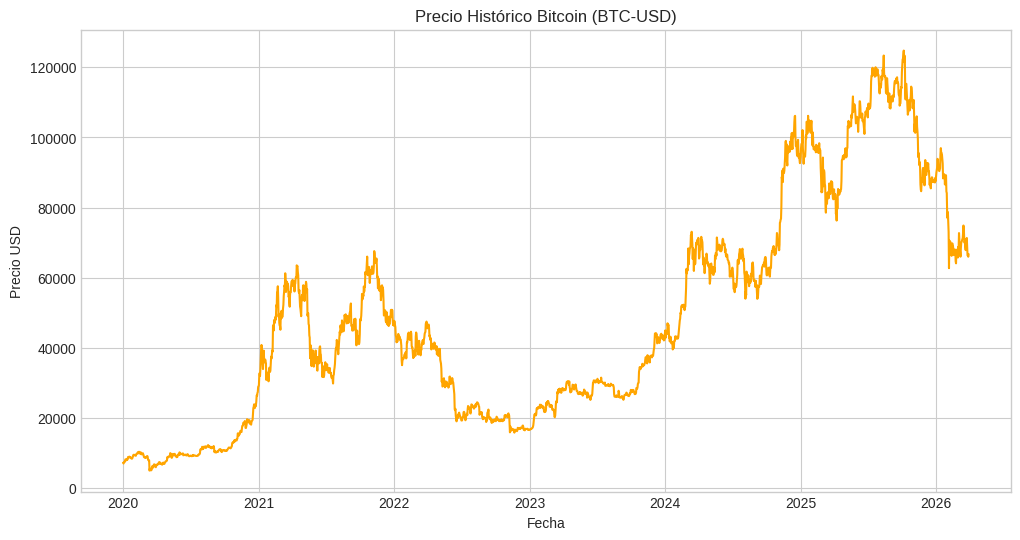

In [ ]:
ticker = "BTC-USD"

data = yf.download(
    ticker,
    start="2020-01-01",
    end="2026-03-31"
)

precios = data["Close"].squeeze()

# GRAFICO DE PRECIOS HISTÓRICOS
plt.figure()
plt.plot(precios, color="orange")
plt.title("Precio Histórico Bitcoin (BTC-USD)")
plt.xlabel("Fecha")
plt.ylabel("Precio USD")
plt.show()

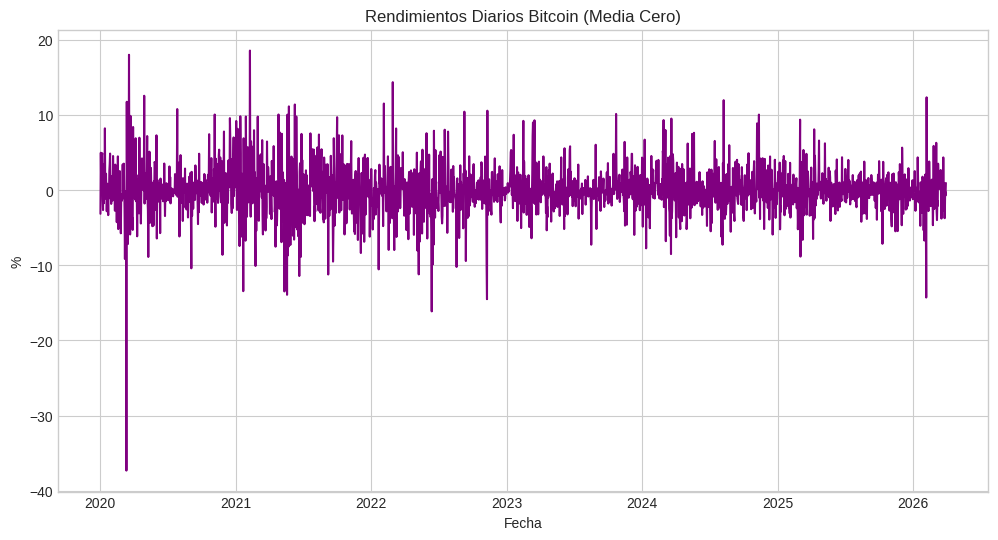

In [ ]:
# CÁLCULO DE RENDIMIENTOS
rendimientos = precios.pct_change().dropna() * 100

# MEDIA CERO
media_rend = rendimientos.mean()
rend_mc = rendimientos - media_rend

plt.figure()
plt.plot(rend_mc, color="purple")
plt.title("Rendimientos Diarios Bitcoin (Media Cero)")
plt.xlabel("Fecha")
plt.ylabel("%")
plt.show()



========== PRUEBA ADF ==========
ADF Statistic : -15.6477
p-value       : 1.6107e-28
Conclusión: Serie estacionaria.


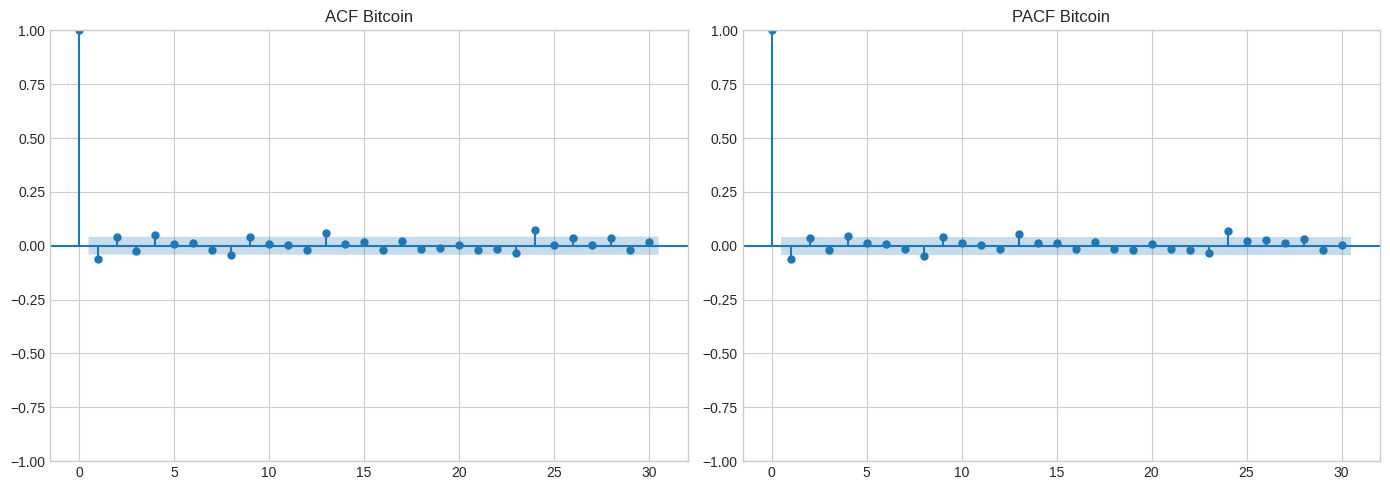

In [ ]:
# PRUEBA DE ESTACIONARIEDAD
resultado_adf = adfuller(rend_mc)

print("========== PRUEBA ADF ==========")
print(f"ADF Statistic : {resultado_adf[0]:.4f}")
print(f"p-value       : {resultado_adf[1]:.4e}")

if resultado_adf[1] < 0.05:
    print("Conclusión: Serie estacionaria.")
else:
    print("Conclusión: Serie NO estacionaria.")

# ACF Y PACF
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

plot_acf(rend_mc, lags=30, ax=ax1)
ax1.set_title("ACF Bitcoin")

plot_pacf(rend_mc, lags=30, ax=ax2, method="ywm")
ax2.set_title("PACF Bitcoin")

plt.tight_layout()
plt.show()



                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                 2280
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -5870.253
Date:                Sat, 18 Apr 2026   AIC                          11752.506
Time:                        03:39:06   BIC                          11786.898
Sample:                    01-02-2020   HQIC                         11765.050
                         - 03-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.138e-05      0.093     -0.001      0.999      -0.182       0.182
ar.L1          0.3472      0.126      2.760      0.006       0.101       0.594
ar.L2          0.6219      0.125      4.992      0.0

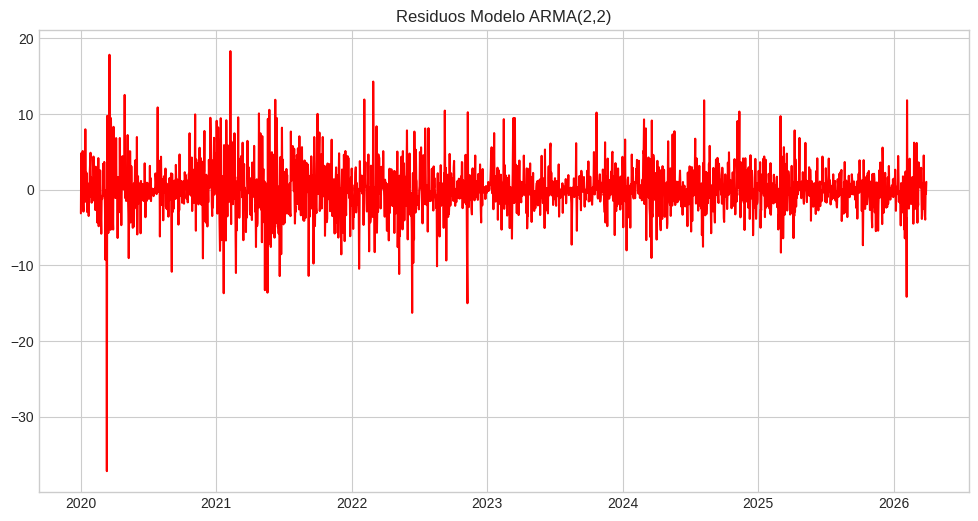

In [ ]:
# AJUSTE MODELO ARMA

modelo = ARIMA(rend_mc, order=(2,0,2))
resultado = modelo.fit()

print(resultado.summary())

# Residuos
residuos = resultado.resid

plt.figure()
plt.plot(residuos, color="red")
plt.title("Residuos Modelo ARMA(2,2)")
plt.show()


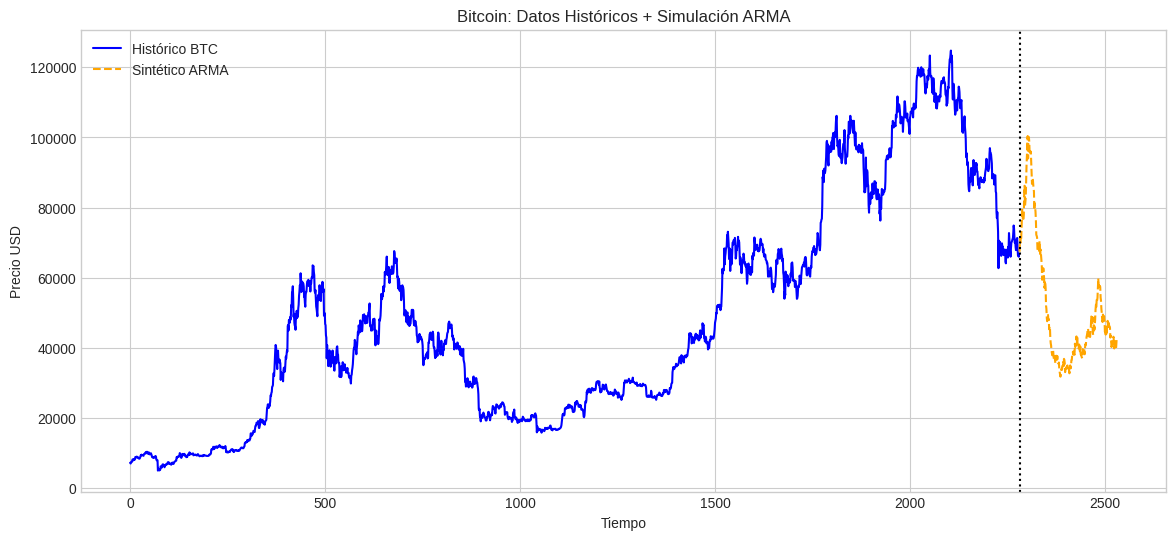

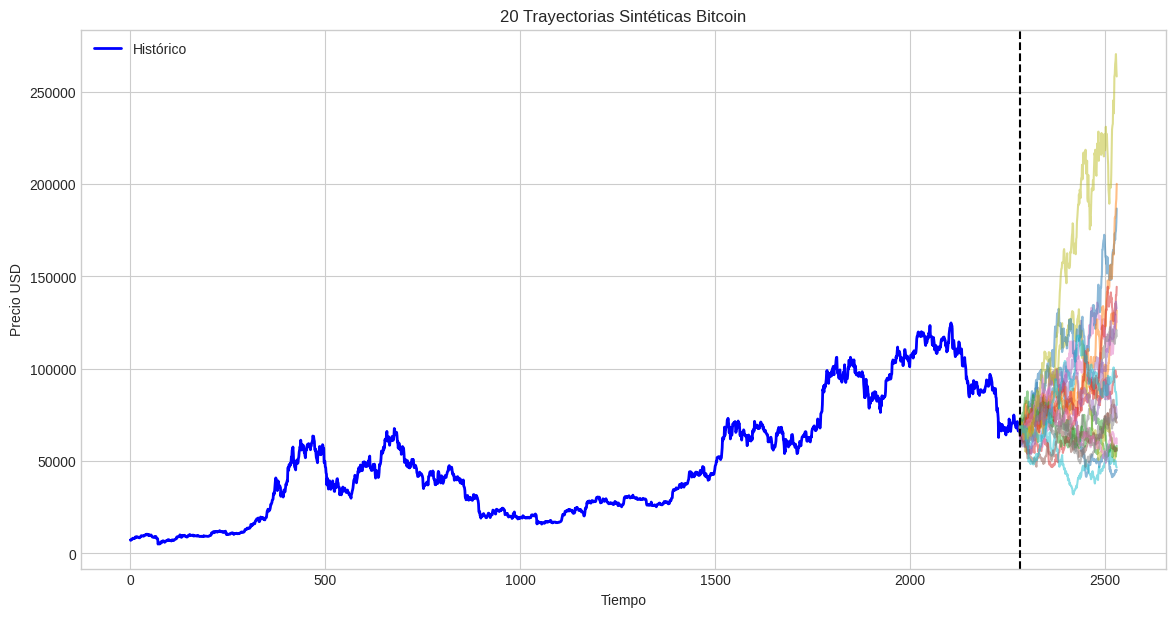

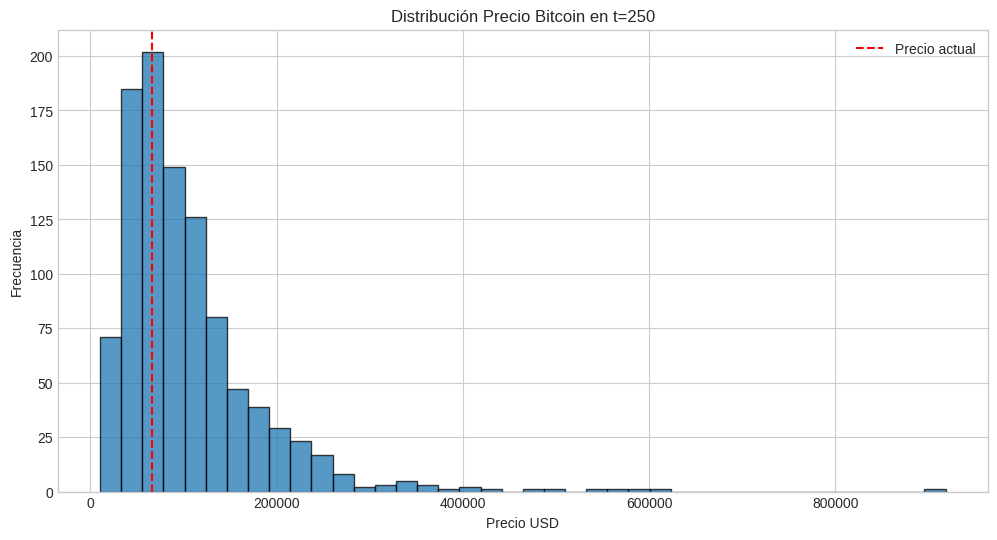

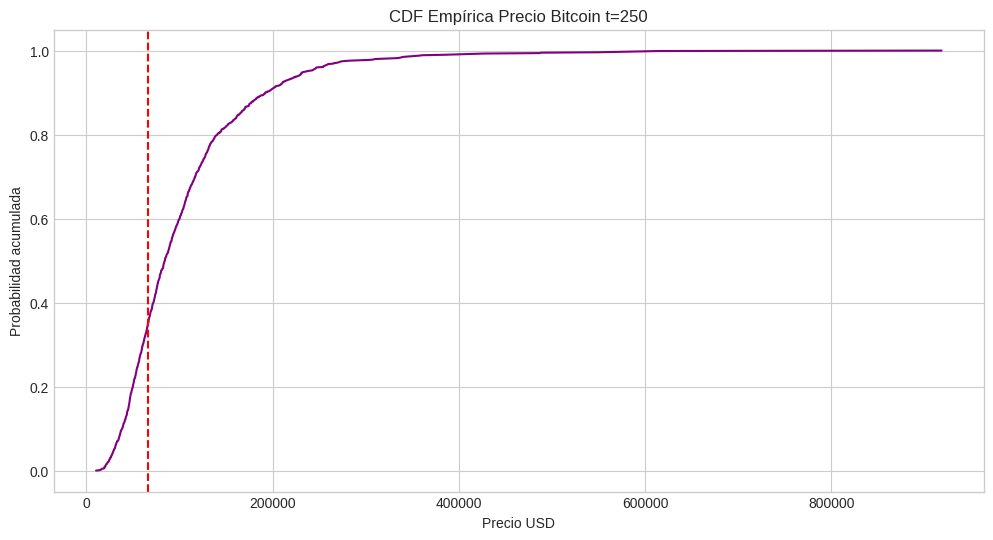

Precio actual BTC : 66691.45
P( BTC_t250 < Precio actual ) = 0.3530
Equivale a 35.30%


In [ ]:
# GENERAR DATOS SINTÉTICOS
dias = 250

rend_sint_mc = resultado.simulate(nsimulations=dias)

# Recuperar media original
rend_sint = rend_sint_mc + media_rend

# Reconstrucción de precios
precio_inicial = precios.iloc[-1]

precios_sint = precio_inicial * (1 + rend_sint/100).cumprod()

# GRAFICAR HISTÓRICO + PROYECCIÓN

plt.figure(figsize=(14,6))
plt.plot(np.arange(len(precios)), precios.values, label="Histórico BTC", color="blue")
plt.plot(np.arange(len(precios), len(precios)+dias),precios_sint.values,label="Sintético ARMA", linestyle="--", color="orange")
plt.axvline(len(precios), color="black", linestyle=":")
plt.title("Bitcoin: Datos Históricos + Simulación ARMA")
plt.xlabel("Tiempo")
plt.ylabel("Precio USD")
plt.legend()
plt.show()

# 1000 REALIZACIONES
n_sim = 1000
trayectorias = np.zeros((n_sim, dias))

for i in range(n_sim):

    r_mc = resultado.simulate(nsimulations=dias)
    r = r_mc + media_rend

    p = precio_inicial * (1 + r/100).cumprod()

    trayectorias[i,:] = p.values


# GRAFICAR 20 TRAYECTORIAS
plt.figure(figsize=(14,7))

plt.plot(np.arange(len(precios)),
         precios.values,
         color="blue",
         linewidth=2,
         label="Histórico")

for i in range(20):
    plt.plot(np.arange(len(precios), len(precios)+dias),
             trayectorias[i,:],
             alpha=0.5)

plt.axvline(len(precios), color="black", linestyle="--")
plt.title("20 Trayectorias Sintéticas Bitcoin")
plt.xlabel("Tiempo")
plt.ylabel("Precio USD")
plt.legend()
plt.show()

# HISTOGRAMA
precios_t250 = trayectorias[:, -1]

plt.figure()
plt.hist(precios_t250, bins=40, edgecolor="black", alpha=0.75)
plt.axvline(precio_inicial, color="red", linestyle="--",
            label="Precio actual")
plt.title("Distribución Precio Bitcoin en t=250")
plt.xlabel("Precio USD")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# CDF EMPÍRICA
x = np.sort(precios_t250)
cdf = np.arange(1, len(x)+1)/len(x)

plt.figure()
plt.plot(x, cdf, color="purple")
plt.axvline(precio_inicial, color="red", linestyle="--")
plt.title("CDF Empírica Precio Bitcoin t=250")
plt.xlabel("Precio USD")
plt.ylabel("Probabilidad acumulada")
plt.grid(True)
plt.show()

# PROBABILIDAD DE CAER POR DEBAJO DEL PRECIO ACTUAL
prob = np.mean(precios_t250 < precio_inicial)

print(f"Precio actual BTC : {precio_inicial:.2f}")
print(f"P( BTC_t250 < Precio actual ) = {prob:.4f}")
print(f"Equivale a {prob*100:.2f}%")